In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df=pd.read_csv("Zomato Dataset.csv")
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [4]:
df.shape

df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

In [6]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min)
count,43730.000000,43676.000000,45584.000000,45584.000000,45584.000000,45584.000000,45584.000000,44591.000000,45584.000000
mean,29.566911,4.633774,17.017948,70.229684,17.465480,70.844161,1.023385,0.744635,26.293963
std,5.815064,0.334744,8.185674,22.885575,7.335562,21.120578,0.839055,0.572510,9.384298
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.551440,75.897963,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


data cleaning


In [8]:
df.isnull().sum() #check missing values

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,1854
Delivery_person_Ratings,1908
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1731


In [9]:
df.duplicated().sum()

np.int64(0)

In [17]:
#remove spaces
for col in df.columns:
  if df[col].dtype=="object":
    df[col]=df[col].str.strip()


In [18]:
for col in df.columns:
    if df[col].dtype == "object":
        print(col)
        print(df[col].unique()[:10])

ID
['0xcdcd' '0xd987' '0x2784' '0xc8b6' '0xdb64' '0x3af3' '0x3aab' '0x689b'
 '0x6f67' '0xc9cf']
Delivery_person_ID
['DEHRES17DEL01' 'KOCRES16DEL01' 'PUNERES13DEL03' 'LUDHRES15DEL02'
 'KNPRES14DEL02' 'MUMRES15DEL03' 'MYSRES01DEL01' 'PUNERES20DEL01'
 'HYDRES14DEL01' 'KOLRES15DEL03']
Order_Date
['12-02-2022' '13-02-2022' '04-03-2022' '14-02-2022' '02-04-2022'
 '01-03-2022' '16-03-2022' '20-03-2022' '15-02-2022' '10-03-2022']
Time_Orderd
['21:55' '14:55' '17:30' '09:20' '19:50' '20:25' '20:30' '20:40' '21:15'
 '20:20']
Time_Order_picked
['22:10' '15:05' '17:40' '09:30' '20:05' '20:35' '15:10' '20:40' '20:50'
 '21:30']
Weather_conditions
['Fog' 'Stormy' 'Sandstorms' 'Windy' 'Cloudy' 'Sunny' nan]
Road_traffic_density
['Jam' 'High' 'Medium' 'Low' nan]
Type_of_order
['Snack' 'Meal' 'Drinks' 'Buffet']
Type_of_vehicle
['motorcycle' 'scooter' 'electric_scooter' 'bicycle']
Festival
['No' 'Yes' nan]
City
['Metropolitian' 'Urban' 'Semi-Urban' nan]


In [19]:
#replace "Nan"
df.replace("NaN", np.nan,inplace=True)
df.replace("Nan", np.nan,inplace=True)
df.replace("nan", np.nan,inplace=True)

In [20]:
df.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,1854
Delivery_person_Ratings,1908
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1731


In [21]:
df['Order_Date']=pd.to_datetime(df['Order_Date'], dayfirst=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           45584 non-null  object        
 1   Delivery_person_ID           45584 non-null  object        
 2   Delivery_person_Age          43730 non-null  float64       
 3   Delivery_person_Ratings      43676 non-null  float64       
 4   Restaurant_latitude          45584 non-null  float64       
 5   Restaurant_longitude         45584 non-null  float64       
 6   Delivery_location_latitude   45584 non-null  float64       
 7   Delivery_location_longitude  45584 non-null  float64       
 8   Order_Date                   45584 non-null  datetime64[ns]
 9   Time_Orderd                  43853 non-null  object        
 10  Time_Order_picked            45584 non-null  object        
 11  Weather_conditions           44968 non-nu

Feature Engineering

In [23]:
df["Month"]=df['Order_Date'].dt.month_name()

In [24]:
df["Day"]=df['Order_Date'].dt.day_name()

In [25]:
df["Weekend"]=( df["Day"].isin(["Saturday", "Sunday"]))

In [26]:
df["Delivery_person_Age"].describe()

,Delivery_person_Age
count,43730.000000
mean,29.566911
std,5.815064
min,15.000000
25%,25.000000
50%,30.000000
75%,35.000000
max,50.000000


In [27]:
df["Delivery_person_Age"]=(df["Delivery_person_Age"].fillna(df["Delivery_person_Age"].median()))

In [28]:
df["Delivery_person_Ratings"] = (
    df["Delivery_person_Ratings"]
    .fillna(
        df["Delivery_person_Ratings"].median()
    )
)

In [29]:
df["multiple_deliveries"] = (
    df["multiple_deliveries"]
    .fillna(
        df["multiple_deliveries"].mode()[0]
    )
)

cleaning categorical columns


In [30]:
df['Weather_conditions']=(
    df['Weather_conditions'].fillna(
        df['Weather_conditions'].mode()[0]
    )
)

In [31]:
df["Road_traffic_density"] = (
    df["Road_traffic_density"]
    .fillna(
        df["Road_traffic_density"].mode()[0]
    )
)

In [32]:
df["Festival"] = (
    df["Festival"]
    .fillna(
        df["Festival"].mode()[0]
    )
)

In [33]:
df["City"] = (
    df["City"]
    .fillna(
        df["City"].mode()[0]
    )
)

In [34]:
df.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1731


UNIVARIATE ANALYSIS


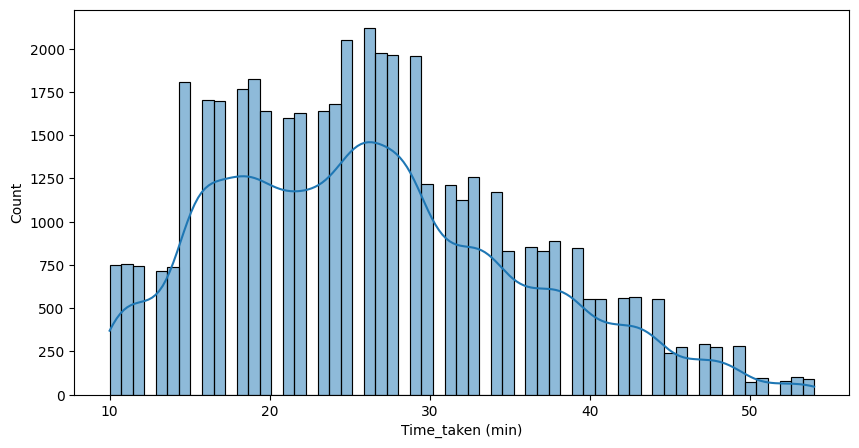

In [37]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Time_taken (min)"],
    kde=True
)

plt.show()

In [38]:
df["Time_taken (min)"].describe()

,Time_taken (min)
count,45584.000000
mean,26.293963
std,9.384298
min,10.000000
25%,19.000000
50%,26.000000
75%,32.000000
max,54.000000


Q: Traffic condition

In [42]:
traffic_avg= (
    df.groupby("Road_traffic_density") ["Time_taken (min)"].mean().sort_values()
)

traffic_avg

,Time_taken (min)
Road_traffic_density,
Low,21.266671
Medium,26.699680
High,27.240109
Jam,31.176038


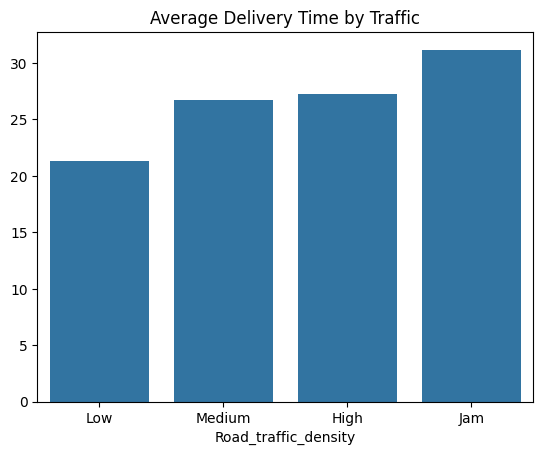

In [43]:
sns.barplot(
    x=traffic_avg.index,
    y=traffic_avg.values
)

plt.title(
    "Average Delivery Time by Traffic"
)

plt.show()

In [44]:
#Q: Weather impact
weather_avg=(
    df.groupby("Weather_conditions")["Time_taken (min)"].mean()
)

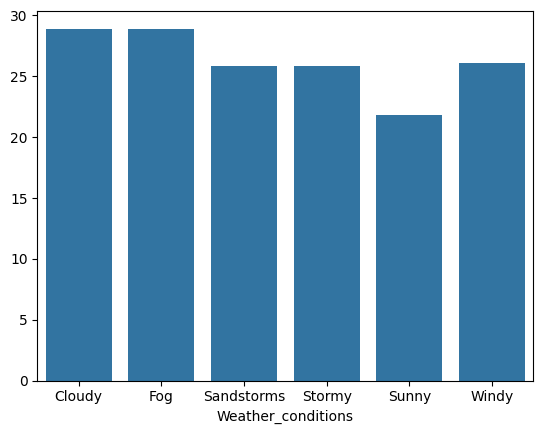

In [48]:
sns.barplot(
    x=weather_avg.index,
    y=weather_avg.values
)
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Festival', ylabel='Time_taken (min)'>

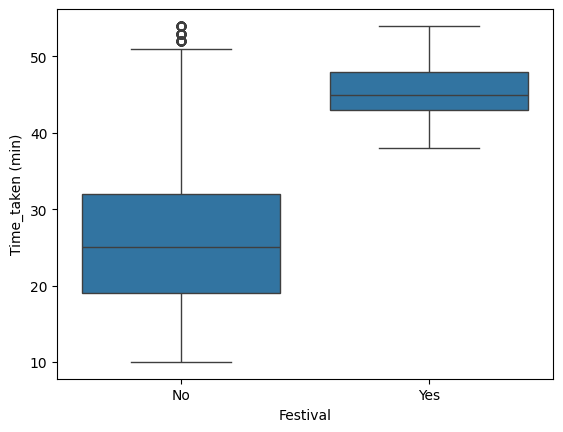

In [49]:
sns.boxplot(
    x="Festival",
    y="Time_taken (min)",
    data=df
)

<Axes: xlabel='Type_of_vehicle', ylabel='Time_taken (min)'>

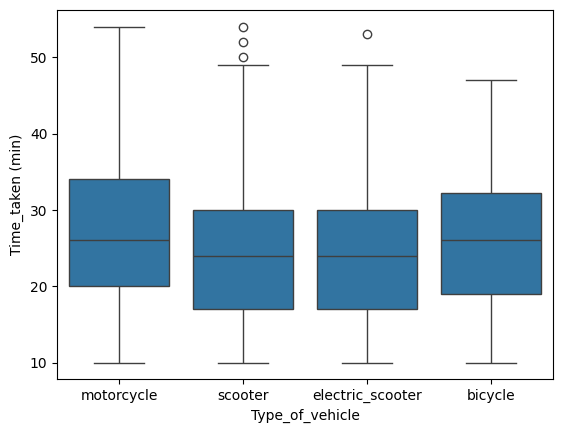

In [50]:
sns.boxplot(
    x="Type_of_vehicle",
    y="Time_taken (min)",
    data=df
)

<Axes: >

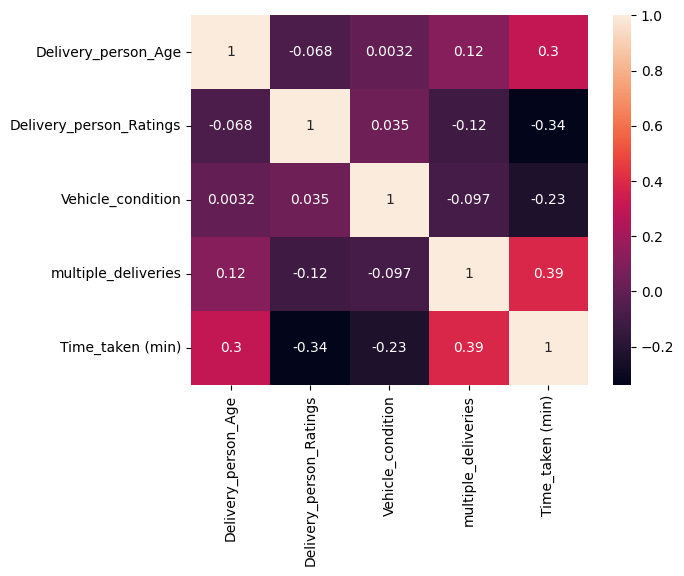

In [51]:
numeric_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Vehicle_condition",
    "multiple_deliveries",
    "Time_taken (min)"
]

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True
)

Distance calculation using haversine formula

In [55]:
from math import radians
from math import sin
from math import cos
from math import sqrt
from math import atan2

def haversine(lat1,lon1, lat2,lon2):
  R=6371
  lat1=radians(lat1);
  lon1=radians(lon1)
  lat2=radians(lat2)
  lon2=radians(lon2)

  dlat=lat2-lat1
  dlon=lon2-lon1


  a = (
        sin(dlat/2)**2
        +
        cos(lat1)
        *
        cos(lat2)
        *
        sin(dlon/2)**2
    )

  c = 2 * atan2(
        sqrt(a),
        sqrt(1-a)
    )

  return R * c


In [62]:
df[[
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude"
]].head()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
0,30.327968,78.046106,30.397968,78.116106
1,10.003064,76.307589,10.043064,76.347589
2,18.562450,73.916619,18.652450,74.006619
3,30.899584,75.809346,30.919584,75.829346
4,26.463504,80.372929,26.593504,80.502929


In [63]:
df[df["Distance_km"] > 50].shape

(431, 21)

In [73]:
df["Distance_km"]=df.apply(
    lambda row: haversine(
        row["Restaurant_latitude"],
        row["Restaurant_longitude"],
        row["Delivery_location_latitude"],
        row["Delivery_location_longitude"]
    ), axis=1
)

In [74]:
df["Distance_km"].quantile([
    0.90,
    0.95,
    0.99,
    0.995,
    0.999
])

,Distance_km
0.900,19.395755
0.950,20.179188
0.990,20.968889
0.995,5888.773350
0.999,17650.858355


In [76]:
threshold = df["Distance_km"].quantile(0.99)

print("Threshold:", threshold)

Threshold: 20.96888932863528


In [77]:
df_clean = df[
    df["Distance_km"] <= threshold
].copy()

In [78]:
print("Original Shape:", df.shape)
print("Clean Shape:", df_clean.shape)

Original Shape: (45584, 21)
Clean Shape: (45131, 21)


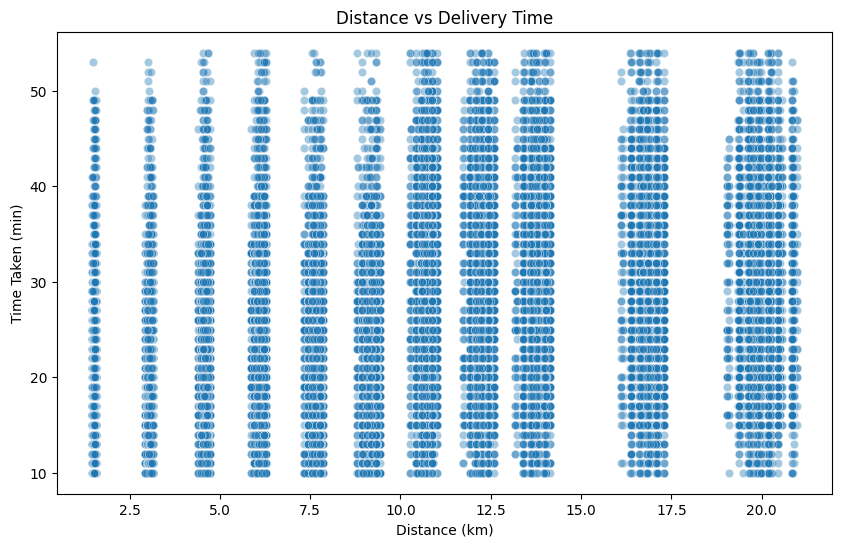

In [79]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="Distance_km",
    y="Time_taken (min)",
    data=df_clean,
    alpha=0.4
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Time Taken (min)")

plt.show()

In [80]:
corr = df_clean[
    ["Distance_km", "Time_taken (min)"]
].corr()

print(corr)  #Distance has a moderate positive relationship with delivery time.3

                  Distance_km  Time_taken (min)
Distance_km           1.00000           0.32181
Time_taken (min)      0.32181           1.00000


In [81]:
df_clean.to_csv(
    "zomato_cleaned.csv",
    index=False
)

In [82]:
traffic_avg = (
    df_clean.groupby("Road_traffic_density")
    ["Time_taken (min)"]
    .mean()
    .sort_values()
)

print(traffic_avg)

Road_traffic_density
Low       21.267326
Medium    26.706878
High      27.226467
Jam       31.181378
Name: Time_taken (min), dtype: float64


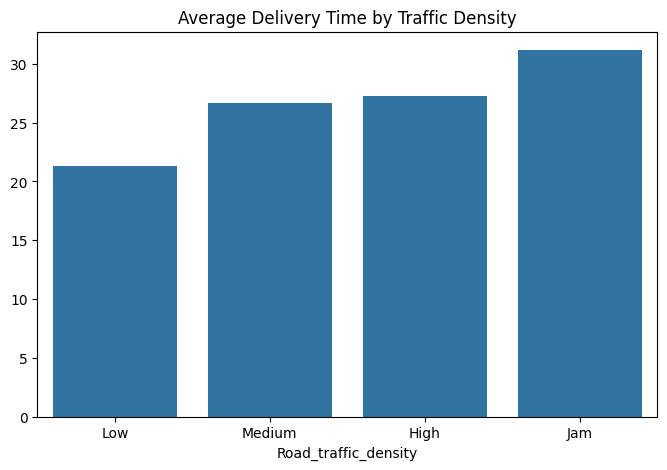

In [83]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=traffic_avg.index,
    y=traffic_avg.values
)

plt.title("Average Delivery Time by Traffic Density")
plt.show()

In [84]:
weather_avg = (
    df_clean.groupby("Weather_conditions")
    ["Time_taken (min)"]
    .mean()
    .sort_values()
)

print(weather_avg)

Weather_conditions
Sunny         21.853746
Stormy        25.863341
Sandstorms    25.872950
Windy         26.127559
Cloudy        28.917480
Fog           28.932123
Name: Time_taken (min), dtype: float64


In [85]:
multiple_avg = (
    df_clean.groupby("multiple_deliveries")
    ["Time_taken (min)"]
    .mean()
)

print(multiple_avg)

multiple_deliveries
0.0    22.873773
1.0    26.858143
2.0    40.444726
3.0    47.812325
Name: Time_taken (min), dtype: float64


In [86]:
festival_avg = (
    df_clean.groupby("Festival")
    ["Time_taken (min)"]
    .mean()
)

print(festival_avg)

Festival
No     25.988914
Yes    45.509050
Name: Time_taken (min), dtype: float64


In [87]:
df_clean[
    ["Delivery_person_Ratings",
     "Time_taken (min)"]
].corr()

,Delivery_person_Ratings,Time_taken (min)
Delivery_person_Ratings,1.000000,-0.344107
Time_taken (min),-0.344107,1.000000


In [88]:
summary = pd.DataFrame({
    "Metric": [
        "Average Delivery Time",
        "Median Delivery Time",
        "Average Distance"
    ],
    "Value": [
        df_clean["Time_taken (min)"].mean(),
        df_clean["Time_taken (min)"].median(),
        df_clean["Distance_km"].mean()
    ]
})

summary

,Metric,Value
0,Average Delivery Time,26.296382
1,Median Delivery Time,26.000000
2,Average Distance,9.729642


In [90]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=summary)

https://docs.google.com/spreadsheets/d/1j9mKniC2rapOT3BetjqS27C7Y4ps8E6Guf09vBYYEug/edit#gid=0
